# Gradient-as-Bucket-View Parameter Sweep Analysis

Plots results from `run_perf_sweep.sh` to visualize how `gradient_as_bucket_view` improvement scales with parameter count.

In [2]:
!uv pip install matplotlib pandas numpy

Using Python 3.10.12 environment at: /mydata/Songqian/pytorch-gb/p3
Resolved 14 packages in 423ms                                        
⠙ Preparing packages... (0/10)                                                  
⠙ Preparing packages... (0/10)------------------     0 B/317.41 KiB          
⠙ Preparing packages... (0/10)------------------     0 B/317.41 KiB          
contourpy            ------------------------------     0 B/317.41 KiB
⠙ Preparing packages... (0/10)------------------     0 B/340.35 KiB          
contourpy            ------------------------------     0 B/317.41 KiB
⠙ Preparing packages... (0/10)------------------     0 B/340.35 KiB          
contourpy            ------------------------------     0 B/317.41 KiB
⠙ Preparing packages... (0/10)------------------     0 B/340.35 KiB          
contourpy            ------------------------------     0 B/317.41 KiB
tzdata               ------------------------------     0 B/340.35 KiB
⠙ Preparing packages... (0/10)------

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import glob
import os

In [82]:
# Find the latest sweep result, or set manually
sweep_dirs = sorted(glob.glob("../ddp-example/data/sweep_*/sweep_results.csv"))
if sweep_dirs:
    CSV_PATH = sweep_dirs[-1]
    print(f"Using latest: {CSV_PATH}")
else:
    CSV_PATH = "../ddp-example/data/sweep_20260302_194008/sweep_results.csv"  # <-- set manually
    print(f"No sweep found. Set CSV_PATH manually.")

Using latest: ../ddp-example/data/sweep_20260316_170019/sweep_results.csv


In [83]:
df = pd.read_csv(CSV_PATH)

for col in ["init_views_gb0_total", "init_views_gb1_total"]:
    if col not in df.columns:
        df[col] = 0

baseline = df["init_views_gb0_total"].replace(0, np.nan)
df["init_views_improve_pct"] = (
    (df["init_views_gb0_total"] - df["init_views_gb1_total"]) / baseline
) * 100
df["init_views_improve_pct"] = df["init_views_improve_pct"].fillna(0.0)

df


,num_params,expo,bwd_gb0_mean,bwd_gb0_std,bwd_gb1_mean,bwd_gb1_std,bwd_improve_pct,iter_gb0_mean,iter_gb0_std,iter_gb1_mean,...,iter_improve_pct,fwd_copy_gb0_mean,fwd_copy_gb1_mean,fwd_copy_improve_pct,rev_copy_gb0_mean,rev_copy_gb1_mean,rev_copy_improve_pct,init_views_gb0_total,init_views_gb1_total,init_views_improve_pct
0,32768,15,0.000517,0.000015,0.000491,0.000033,5.03,0.000906,0.000028,0.000859,...,5.27,34,33,2.9,31,0,100.0,54,111,-105.555556
1,65536,16,0.000527,0.000010,0.000492,0.000020,6.74,0.000883,0.000017,0.000844,...,4.43,34,33,2.9,31,0,100.0,52,94,-80.769231
2,131072,17,0.000547,0.000014,0.000521,0.000068,4.82,0.000930,0.000029,0.000901,...,3.10,34,33,2.9,31,0,100.0,52,95,-82.692308
3,262144,18,0.000547,0.000010,0.000522,0.000024,4.43,0.000930,0.000013,0.000904,...,2.82,34,34,0.0,31,0,100.0,71,95,-33.802817
4,524288,19,0.000759,0.000038,0.000720,0.000016,5.11,0.001199,0.000040,0.001159,...,3.34,51,50,2.0,42,0,100.0,58,137,-136.206897
5,1048576,20,0.001164,0.000026,0.001141,0.000093,1.96,0.001721,0.000049,0.001689,...,1.82,84,79,6.0,62,0,100.0,81,205,-153.086420
6,2097152,21,0.002114,0.000049,0.002124,0.000621,-0.45,0.002868,0.000080,0.002880,...,-0.41,148,142,4.1,103,0,100.0,105,360,-242.857143
7,4194304,22,0.003944,0.000107,0.004036,0.001326,-2.32,0.005098,0.000119,0.005200,...,-2.02,270,262,3.0,185,1,99.5,184,634,-244.565217
8,8388608,23,0.007297,0.000139,0.007050,0.000198,3.39,0.009327,0.000139,0.009136,...,2.06,514,492,4.3,358,2,99.4,355,1206,-239.718310
9,16777216,24,0.012348,0.001665,0.011677,0.000342,5.43,0.016237,0.001847,0.015513,...,4.46,1060,993,6.3,719,5,99.3,747,2572,-244.310576


In [84]:
def format_params(val):
    if val >= 1e6:
        return f"{val/1e6:.0f}M"
    elif val >= 1e3:
        return f"{val/1e3:.0f}K"
    return str(int(val))

x_labels = [format_params(v) for v in df["num_params"]]

## 1. Backward Pass Time: gb=0 vs gb=1

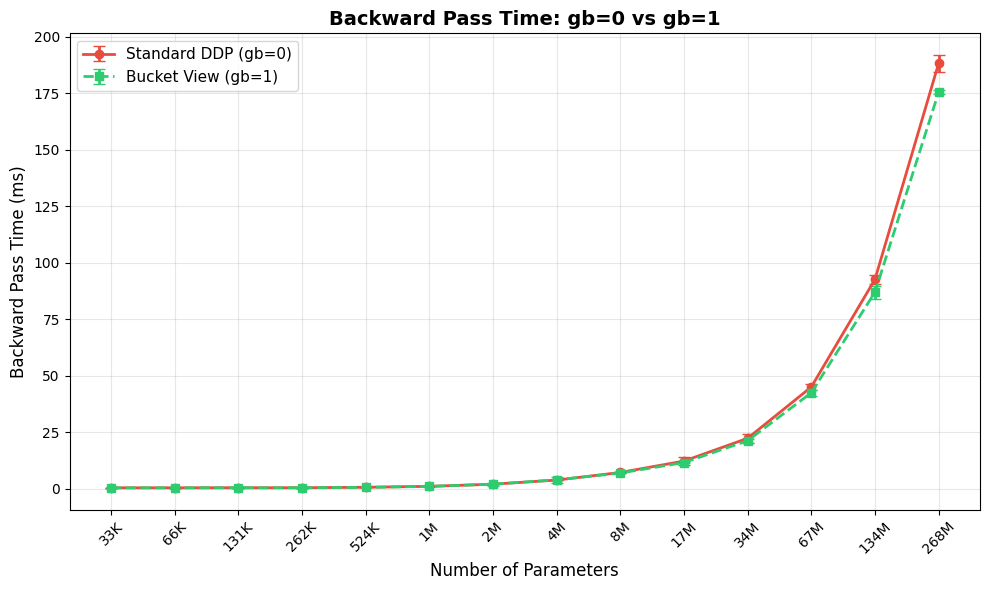

In [85]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(range(len(x_labels)), df["bwd_gb0_mean"] * 1000, yerr=df["bwd_gb0_std"] * 1000,
            fmt="o-", label="Standard DDP (gb=0)", capsize=4, color="#e74c3c", linewidth=2)
ax.errorbar(range(len(x_labels)), df["bwd_gb1_mean"] * 1000, yerr=df["bwd_gb1_std"] * 1000,
            fmt="s--", label="Bucket View (gb=1)", capsize=4, color="#2ecc71", linewidth=2)

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters", fontsize=12)
ax.set_ylabel("Backward Pass Time (ms)", fontsize=12)
ax.set_title("Backward Pass Time: gb=0 vs gb=1", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Backward Pass Improvement %

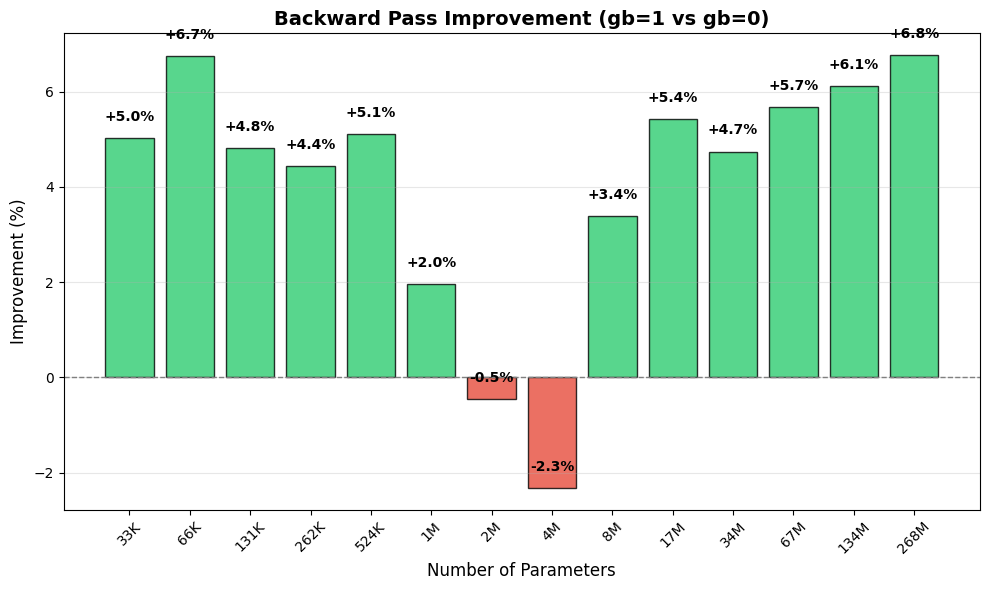

In [86]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in df["bwd_improve_pct"]]
bars = ax.bar(range(len(x_labels)), df["bwd_improve_pct"], color=colors,
              edgecolor="black", alpha=0.8)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")

for bar, val in zip(bars, df["bwd_improve_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:+.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters", fontsize=12)
ax.set_ylabel("Improvement (%)", fontsize=12)
ax.set_title("Backward Pass Improvement (gb=1 vs gb=0)", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Forward Copy Time (grad → bucket): gb=0 vs gb=1

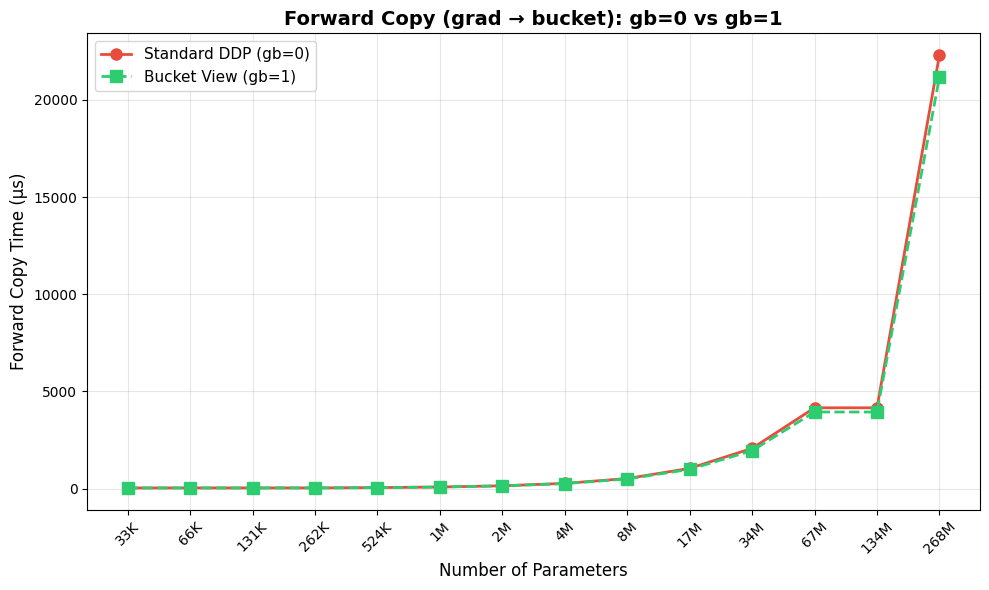

In [76]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(range(len(x_labels)), df["fwd_copy_gb0_mean"], "o-",
        label="Standard DDP (gb=0)", color="#e74c3c", markersize=8, linewidth=2)
ax.plot(range(len(x_labels)), df["fwd_copy_gb1_mean"], "s--",
        label="Bucket View (gb=1)", color="#2ecc71", markersize=8, linewidth=2)

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters", fontsize=12)
ax.set_ylabel("Forward Copy Time (μs)", fontsize=12)
ax.set_title("Forward Copy (grad → bucket): gb=0 vs gb=1", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Forward Copy Improvement %

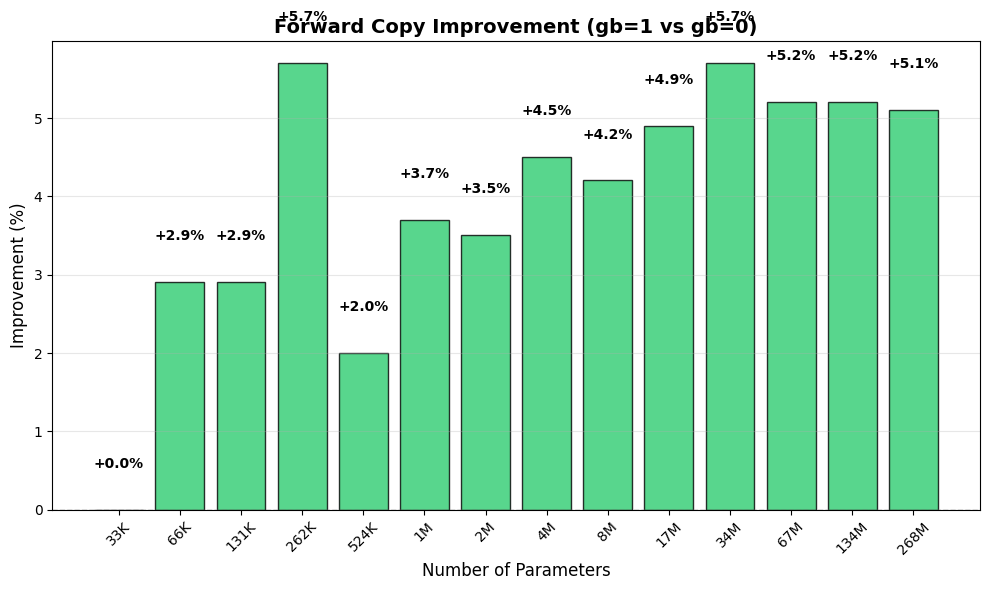

In [77]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in df["fwd_copy_improve_pct"]]
bars = ax.bar(range(len(x_labels)), df["fwd_copy_improve_pct"], color=colors,
              edgecolor="black", alpha=0.8)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")

for bar, val in zip(bars, df["fwd_copy_improve_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:+.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters", fontsize=12)
ax.set_ylabel("Improvement (%)", fontsize=12)
ax.set_title("Forward Copy Improvement (gb=1 vs gb=0)", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Reverse Copy Time (bucket → grad): gb=0 vs gb=1

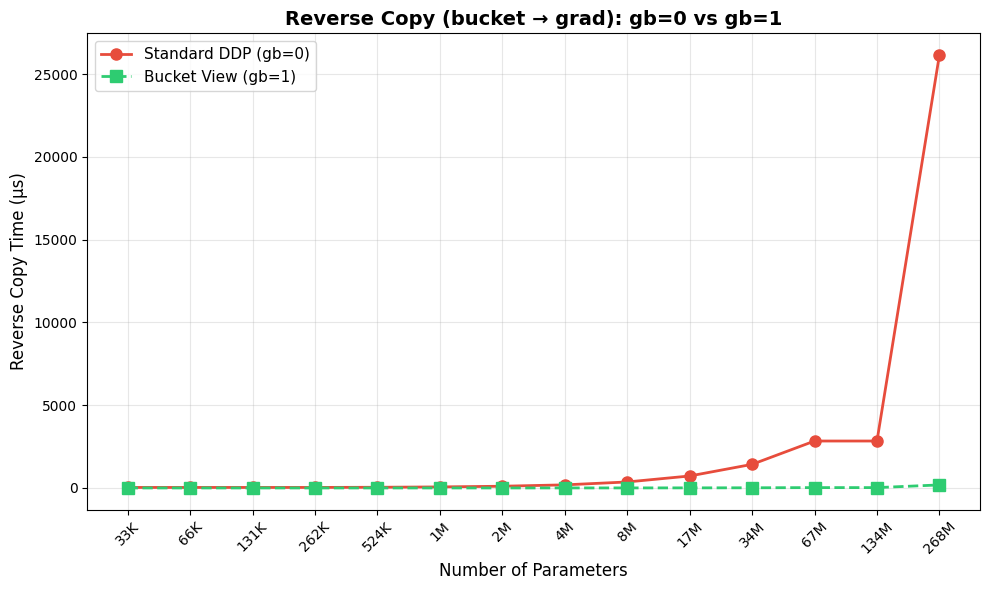

In [78]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(range(len(x_labels)), df["rev_copy_gb0_mean"], "o-",
        label="Standard DDP (gb=0)", color="#e74c3c", markersize=8, linewidth=2)
ax.plot(range(len(x_labels)), df["rev_copy_gb1_mean"], "s--",
        label="Bucket View (gb=1)", color="#2ecc71", markersize=8, linewidth=2)

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters", fontsize=12)
ax.set_ylabel("Reverse Copy Time (μs)", fontsize=12)
ax.set_title("Reverse Copy (bucket → grad): gb=0 vs gb=1", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Reverse Copy Improvement %

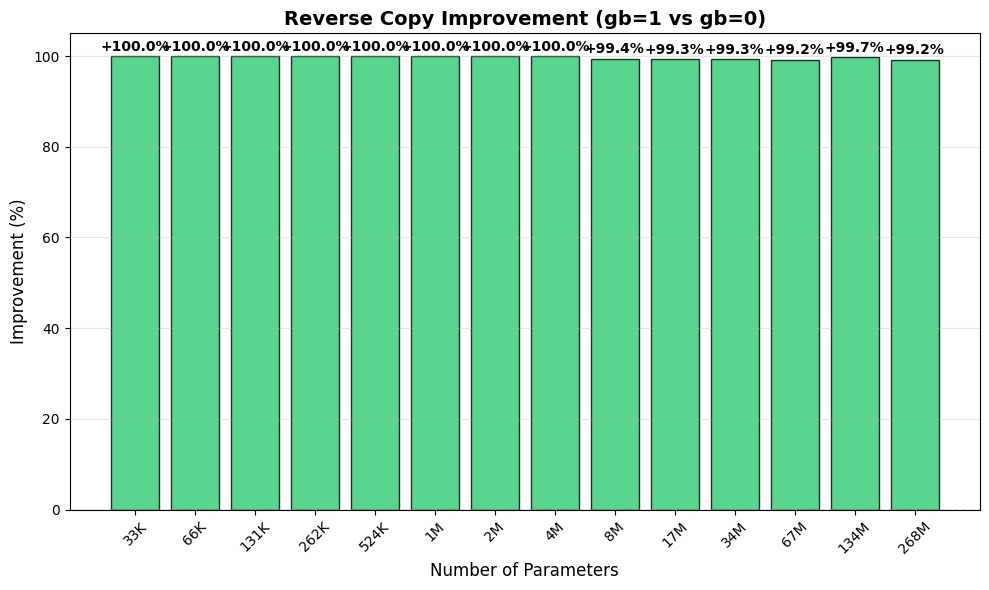

In [69]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in df["rev_copy_improve_pct"]]
bars = ax.bar(range(len(x_labels)), df["rev_copy_improve_pct"], color=colors,
              edgecolor="black", alpha=0.8)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")

for bar, val in zip(bars, df["rev_copy_improve_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:+.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters", fontsize=12)
ax.set_ylabel("Improvement (%)", fontsize=12)
ax.set_title("Reverse Copy Improvement (gb=1 vs gb=0)", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Initial Bucket View Setup Time: gb=0 vs gb=1


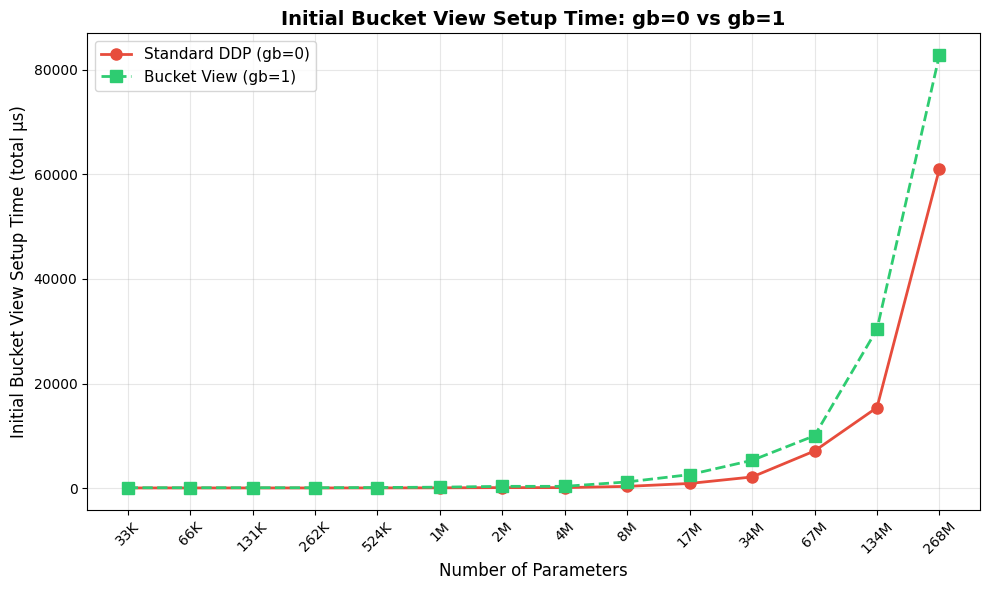

In [70]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(range(len(x_labels)), df["init_views_gb0_total"], "o-",
        label="Standard DDP (gb=0)", color="#e74c3c", markersize=8, linewidth=2)
ax.plot(range(len(x_labels)), df["init_views_gb1_total"], "s--",
        label="Bucket View (gb=1)", color="#2ecc71", markersize=8, linewidth=2)

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters", fontsize=12)
ax.set_ylabel("Initial Bucket View Setup Time (total μs)", fontsize=12)
ax.set_title("Initial Bucket View Setup Time: gb=0 vs gb=1", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Initial Bucket View Setup Improvement %


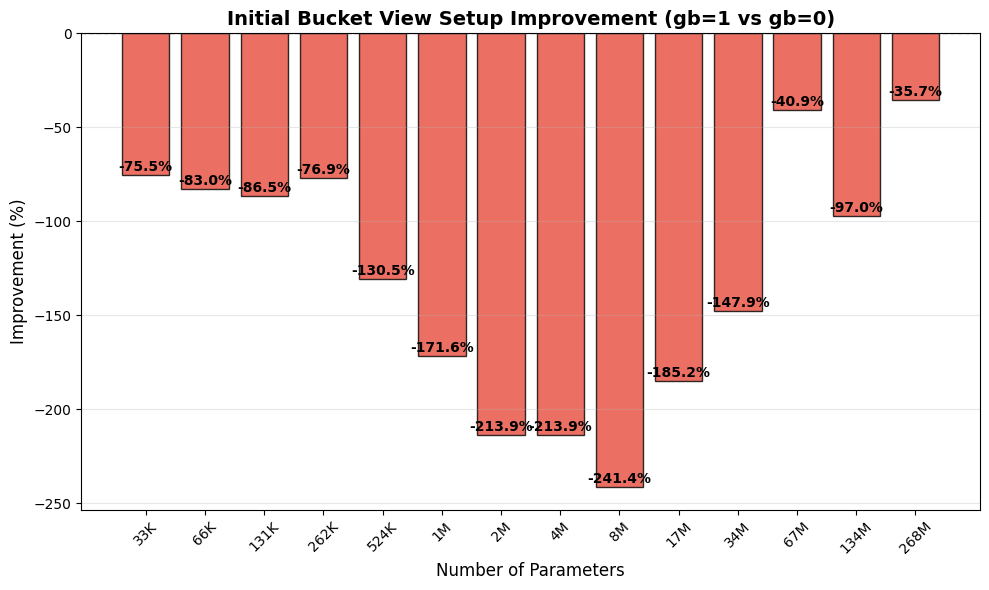

In [60]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in df["init_views_improve_pct"]]
bars = ax.bar(range(len(x_labels)), df["init_views_improve_pct"], color=colors,
              edgecolor="black", alpha=0.8)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")

for bar, val in zip(bars, df["init_views_improve_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:+.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters", fontsize=12)
ax.set_ylabel("Improvement (%)", fontsize=12)
ax.set_title("Initial Bucket View Setup Improvement (gb=1 vs gb=0)", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Combined 4×2 Overview


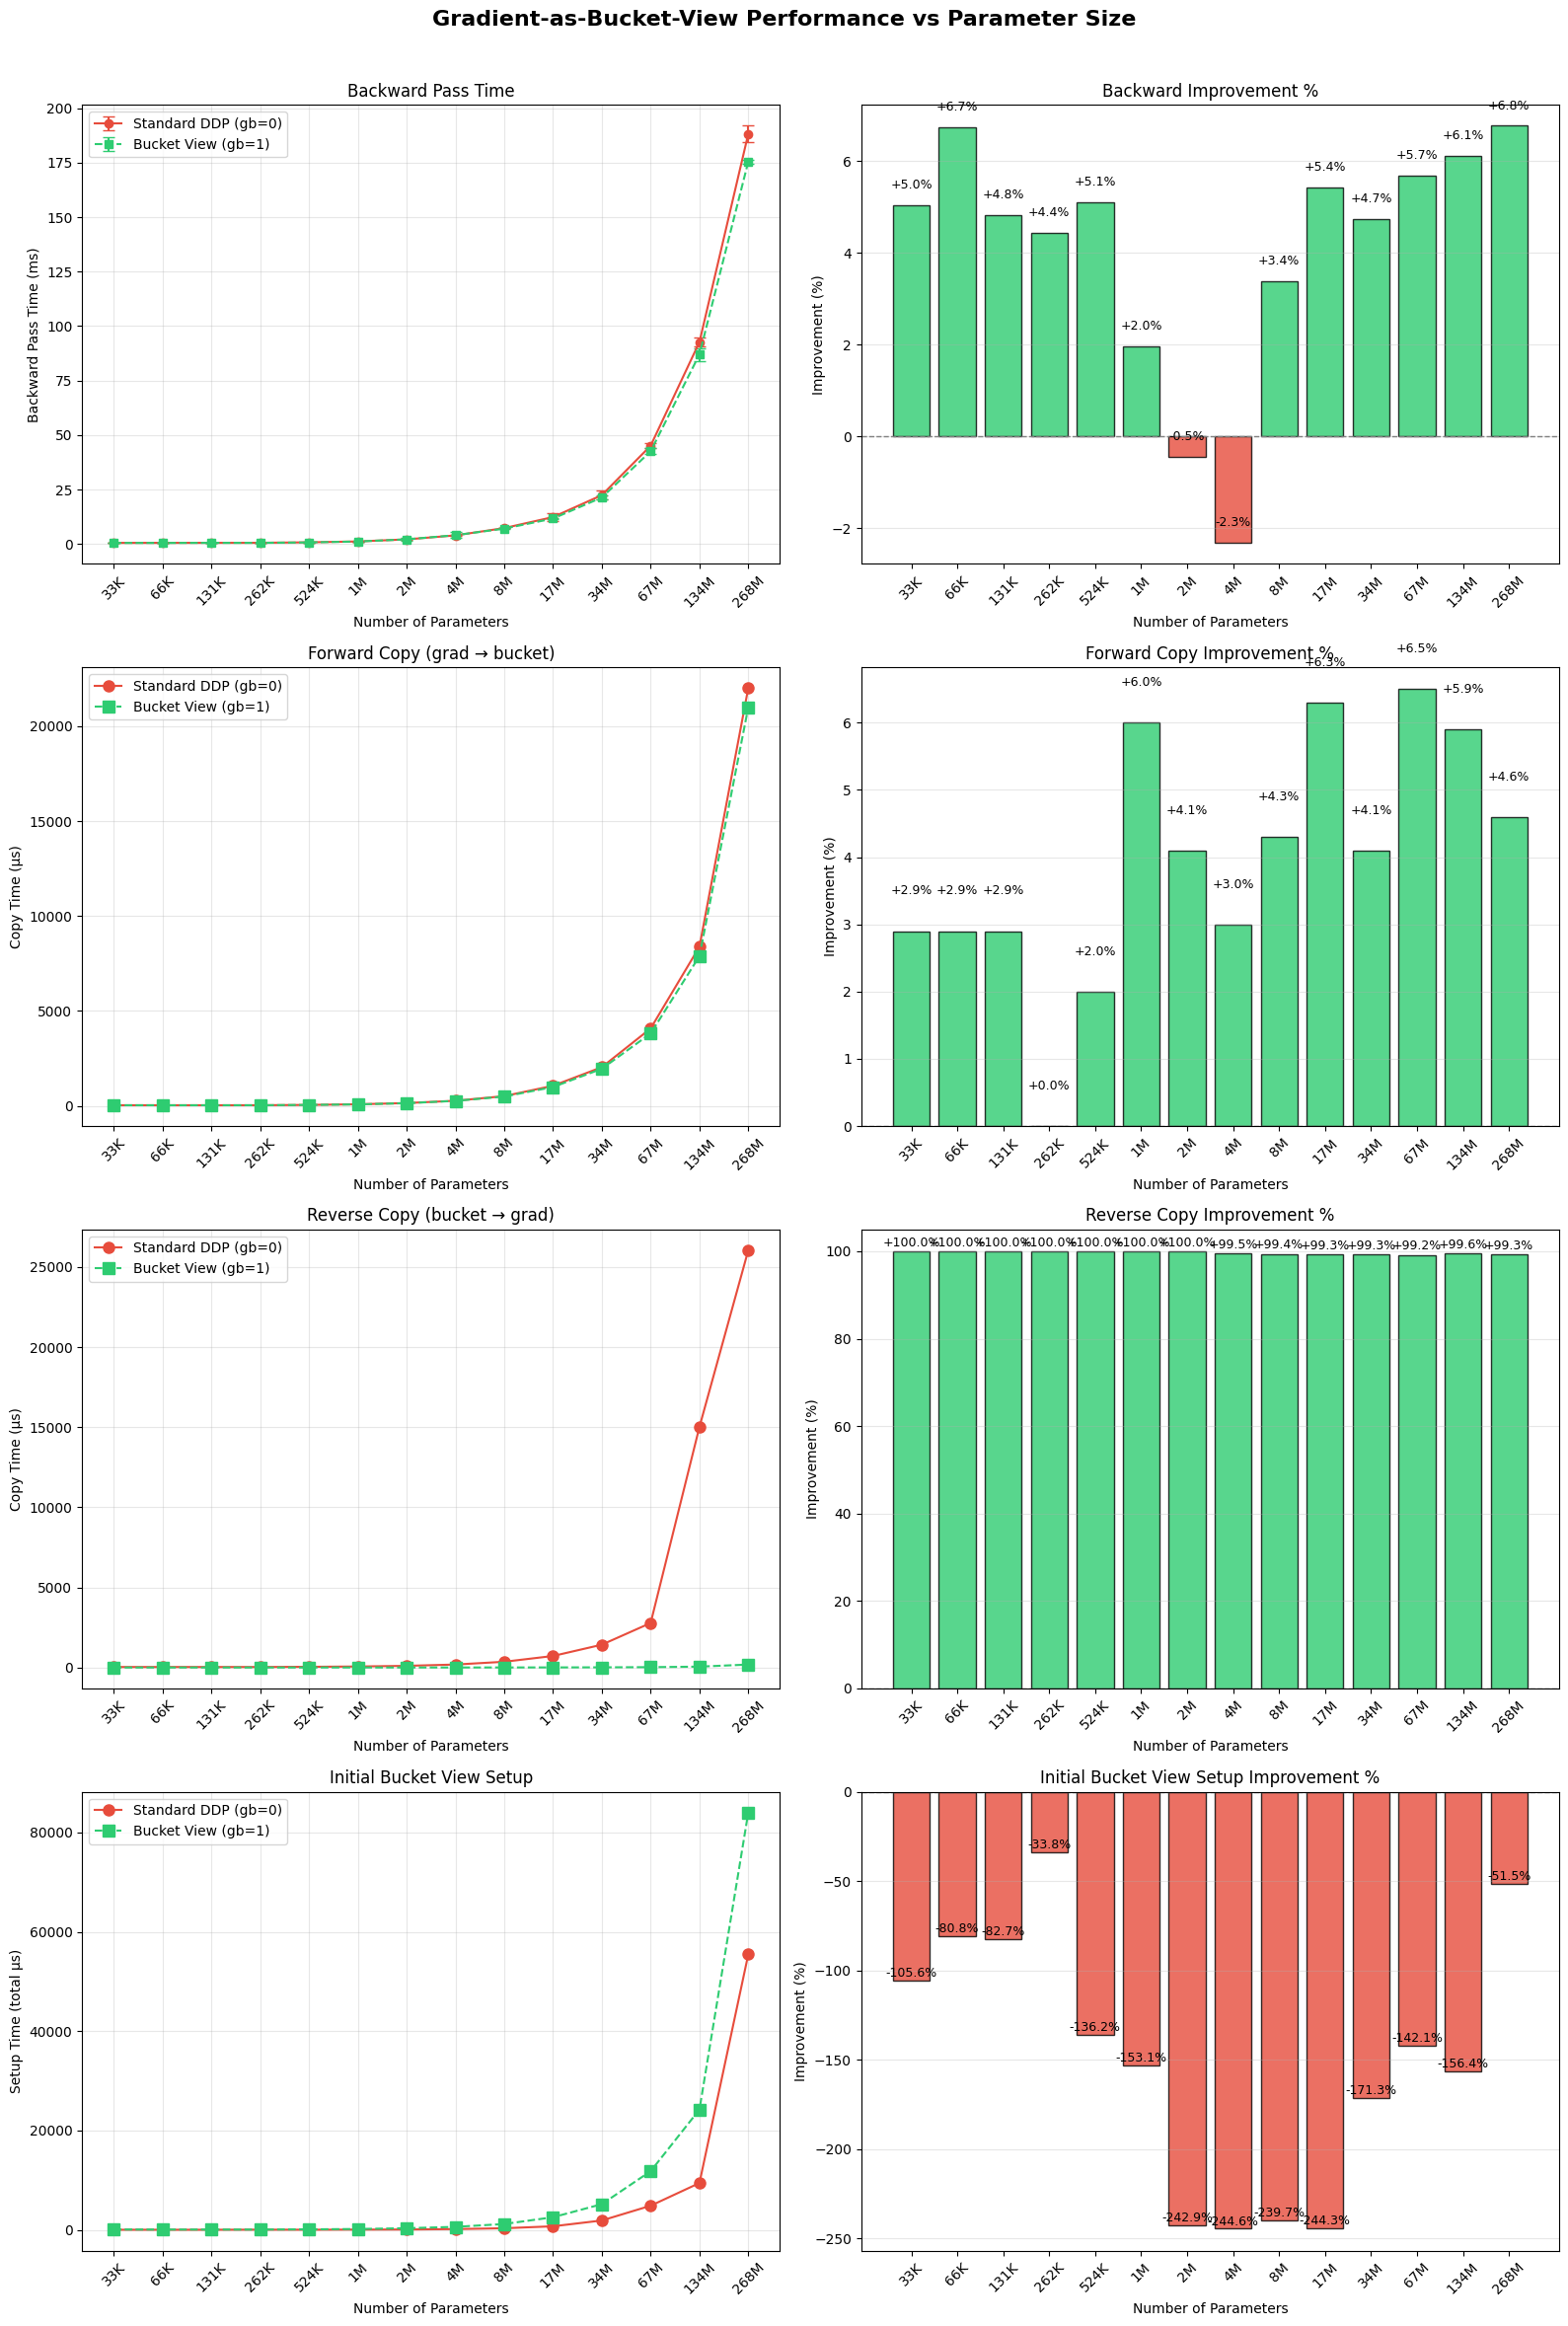

In [81]:
fig, axes = plt.subplots(4, 2, figsize=(16, 24))
fig.suptitle("Gradient-as-Bucket-View Performance vs Parameter Size",
             fontsize=16, fontweight="bold", y=0.98)

# Row 1 Left: Backward time comparison
ax = axes[0, 0]
ax.errorbar(range(len(x_labels)), df["bwd_gb0_mean"] * 1000, yerr=df["bwd_gb0_std"] * 1000,
            fmt="o-", label="Standard DDP (gb=0)", capsize=4, color="#e74c3c")
ax.errorbar(range(len(x_labels)), df["bwd_gb1_mean"] * 1000, yerr=df["bwd_gb1_std"] * 1000,
            fmt="s--", label="Bucket View (gb=1)", capsize=4, color="#2ecc71")
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters")
ax.set_ylabel("Backward Pass Time (ms)")
ax.set_title("Backward Pass Time")
ax.legend()
ax.grid(True, alpha=0.3)

# Row 1 Right: Backward improvement %
ax = axes[0, 1]
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in df["bwd_improve_pct"]]
bars = ax.bar(range(len(x_labels)), df["bwd_improve_pct"], color=colors,
              edgecolor="black", alpha=0.8)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters")
ax.set_ylabel("Improvement (%)")
ax.set_title("Backward Improvement %")
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, df["bwd_improve_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:+.1f}%", ha="center", va="bottom", fontsize=9)

# Row 2 Left: Forward copy time comparison
ax = axes[1, 0]
ax.plot(range(len(x_labels)), df["fwd_copy_gb0_mean"], "o-",
        label="Standard DDP (gb=0)", color="#e74c3c", markersize=8)
ax.plot(range(len(x_labels)), df["fwd_copy_gb1_mean"], "s--",
        label="Bucket View (gb=1)", color="#2ecc71", markersize=8)
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters")
ax.set_ylabel("Copy Time (μs)")
ax.set_title("Forward Copy (grad → bucket)")
ax.legend()
ax.grid(True, alpha=0.3)

# Row 2 Right: Forward copy improvement %
ax = axes[1, 1]
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in df["fwd_copy_improve_pct"]]
bars = ax.bar(range(len(x_labels)), df["fwd_copy_improve_pct"], color=colors,
              edgecolor="black", alpha=0.8)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters")
ax.set_ylabel("Improvement (%)")
ax.set_title("Forward Copy Improvement %")
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, df["fwd_copy_improve_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:+.1f}%", ha="center", va="bottom", fontsize=9)

# Row 3 Left: Reverse copy time comparison
ax = axes[2, 0]
ax.plot(range(len(x_labels)), df["rev_copy_gb0_mean"], "o-",
        label="Standard DDP (gb=0)", color="#e74c3c", markersize=8)
ax.plot(range(len(x_labels)), df["rev_copy_gb1_mean"], "s--",
        label="Bucket View (gb=1)", color="#2ecc71", markersize=8)
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters")
ax.set_ylabel("Copy Time (μs)")
ax.set_title("Reverse Copy (bucket → grad)")
ax.legend()
ax.grid(True, alpha=0.3)

# Row 3 Right: Reverse copy improvement %
ax = axes[2, 1]
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in df["rev_copy_improve_pct"]]
bars = ax.bar(range(len(x_labels)), df["rev_copy_improve_pct"], color=colors,
              edgecolor="black", alpha=0.8)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters")
ax.set_ylabel("Improvement (%)")
ax.set_title("Reverse Copy Improvement %")
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, df["rev_copy_improve_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:+.1f}%", ha="center", va="bottom", fontsize=9)

# Row 4 Left: Initial bucket view setup time comparison
ax = axes[3, 0]
ax.plot(range(len(x_labels)), df["init_views_gb0_total"], "o-",
        label="Standard DDP (gb=0)", color="#e74c3c", markersize=8)
ax.plot(range(len(x_labels)), df["init_views_gb1_total"], "s--",
        label="Bucket View (gb=1)", color="#2ecc71", markersize=8)
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters")
ax.set_ylabel("Setup Time (total μs)")
ax.set_title("Initial Bucket View Setup")
ax.legend()
ax.grid(True, alpha=0.3)

# Row 4 Right: Initial bucket view setup improvement %
ax = axes[3, 1]
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in df["init_views_improve_pct"]]
bars = ax.bar(range(len(x_labels)), df["init_views_improve_pct"], color=colors,
              edgecolor="black", alpha=0.8)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters")
ax.set_ylabel("Improvement (%)")
ax.set_title("Initial Bucket View Setup Improvement %")
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, df["init_views_improve_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:+.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
